In [139]:
fluido = 'g' #g, glicerolo; s, sapone

In [140]:
import math
import importlib
import funzioni as f
importlib.reload(f)

import numpy as np

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation
import itertools
%config InlineBackend.figure_format = 'svg'

import stile_grafici as gf
importlib.reload(gf)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
color_cycle = itertools.cycle(colors)
diameter = ['1.5','2.0','3.2','4.8','6.4']
diameter_cycle = itertools.cycle(diameter)
markers = ['o','s','^','D','v']
marker_cycle = itertools.cycle(markers)
errori = gf.default_error_params()
gf.imposta_stile_globale()

In [141]:
if fluido == 'g':
    input_file = "glicerolo.txt"
    rho_0 = 1260
    srho_0 = 10
    nome = "gli"
    titolo = "Glicerolo"
    colore = '#9467bd'
    
if fluido == 's':
    input_file = "sapone.txt"
    rho_0 = 1032
    srho_0 = 1
    nome = "sap"
    titolo = "Sapone"
    colore = '#2ca02c'

sx = (0.5e-3) / math.sqrt(24) #errore distribuzione triangolare con risoluzione 5mm
st = (0.001) / math.sqrt(12) #errore distribuzione uniforme con risoluzione 0.001s

sd = 1e-5
g = 9.8065855
sg = 0.001
rho = 7870
srho = 1
srho_TOT = math.sqrt( srho**2 + srho_0**2)

R = 0.045
#sR = 0.0001
sR = 0.
h = 0.7
#sh = 0.001
sh = 0.

def correzione(d):
    if (fluido == 'g'):
        r = d/2
        return (1+2.33*(r/R))*(1+3.3*(r/h))
        #return 1
    if (fluido == 's'):
        return 1

def scorrezione(d):
    r = d/2
    sr = sd/2
    termine1 = 1+2.33*(r/R)
    stermine1 = math.sqrt(((2.33 / R) * sr)**2 + ((2.33 * r / (R**2)) * sR)**2)
    termine2 = 1+3.3*(r/h)
    stermine2 = math.sqrt(((3.3 / h) * sr)**2 + ((3.3 * r / (h**2)) * sh)**2)
    if (fluido == 'g'):
        return (stermine1 / termine1)**2 + (stermine2 / termine2)**2
        #return 0
    if (fluido == 's'):
        return 0

# 1. Migliori Stime

### 1.1 Raccolta Dati

Sono state calcolati i valori medi delle quattro misure ripetute dei tempi, usando come incertezza la deviazione standard campionaria. I campioni dei tempi (quattro misure ripetute) non sonon gaussiani il chè vuol dire che fare una media con deviazione standard della media non è molto sensato: si può comunque definire una media(?) ma meglio definire una deviazione standard campionaria.

In [142]:
x_serie = []
t_serie = []
st_serie = []
d_serie = [0.00150,0.00200,0.00318,0.00476,0.00635] #diametri in metri

with open (input_file, "r") as input:

    x = []
    t = []
    st = []

    for riga in input:

        if riga.isspace():
            x_serie.append(x.copy())
            t_serie.append(t.copy())
            st_serie.append(st.copy())
            x.clear()
            t.clear()
            st.clear()
            continue

        x0, t1, t2, t3, t4 = map(float, riga.split())
        t0 = [t1, t2, t3, t4]

        t_medio = f.media(t0)
        #st_medio = f.dev(t0) / math.sqrt(len(t0))
        st_medio = f.dev(t0)

        x.append(x0)
        t.append(t_medio)
        st.append(st_medio)
    
    if x:
        x_serie.append(x.copy())
        t_serie.append(t.copy())
        st_serie.append(st.copy())
        x.clear()
        t.clear()
        st.clear()
del x0, t1, t2, t3, t4, t0, t_medio, st_medio, x, t, st

print(x_serie)
print(t_serie)
print(st_serie)

[[0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5], [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5], [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5], [0.05, 0.15, 0.25, 0.35, 0.45], [0.05, 0.15, 0.25, 0.35, 0.45]]
[[8.69275, 17.551000000000002, 26.403750000000002, 35.345, 44.18125, 53.1365, 62.069, 71.10125, 80.18925, 89.251], [4.7775, 9.71475, 14.641, 19.68175, 24.65575, 29.64, 34.0405, 40.11025, 45.1765, 50.1665], [1.9, 3.884, 5.83675, 7.8555, 9.79225, 11.79125, 13.9465, 15.99375, 18.03775, 20.08575], [0.8635, 2.6477500000000003, 4.46, 6.18075, 7.9865], [0.59825, 1.58625, 2.65375, 3.67475, 4.6935]]
[[0.07285773809280685, 0.15401082213056724, 0.21347814095749063, 0.1521994305727402, 0.23663808512860735, 0.295434707958741, 0.2682473982477105, 0.33756814126928236, 0.3484569557348524, 0.4942745525852342], [0.03529400326778872, 0.08897331060492214, 0.09086987032748187, 0.22004753274387578, 0.10310310373601617, 0.11133133730745667, 1.3832316026850555, 0.62126450351950

### 1.2 Grafico Confronto Andamenti Tempi Caduta

Nome output "nome_confronto_tempi.pdf".

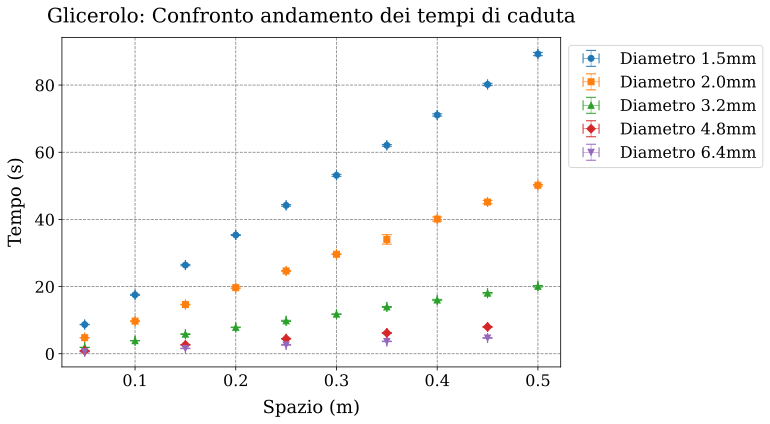

In [143]:
fig, ax = plt.subplots()

for i in range(len(x_serie)):
    color = next(color_cycle)
    diameter = next(diameter_cycle)
    marker = next(marker_cycle)
    label = f"Diametro {diameter}mm"
    ax.errorbar(x_serie[i], t_serie[i], xerr=sx, yerr=st_serie[i], fmt=marker, label=label, color=color, **errori)

gf.setup_2d_axes(ax, titolo = f"{titolo}: Confronto andamento dei tempi di caduta", xlabel = "Spazio (m)", ylabel = "Tempo (s)")

gf.salva_figura(f"{nome}2.pdf")

### 1.3 Interpolazione

Nome output "nome_elaborato_migliori_stime.txt". Da verificare la compatibilità dell'intercetta ("a") con l'origine con un test di Student. Minimi quadrati II con incertezze sui tempi (ordinate) date dalla deviazione standard campionaria, e quindi variabili.

In [144]:
output_name = f"{nome}_elaborato_migliori_stime.txt"
f.output_init(output_name)
with open (output_name, 'w') as file:
    file.write('\n')
for i in range (len(x_serie)):
    f.elaborato(x_serie[i], t_serie[i], st_serie[i], output_name, i)

del output_name

Minimi quadrati II
Processo al calcolatore

Minimi quadrati II
Processo al calcolatore

Minimi quadrati II
Processo al calcolatore

Minimi quadrati II
Processo al calcolatore

Minimi quadrati II
Processo al calcolatore



### 1.4 Calcolo Viscosità

Le liste _falsi contengono le velocità non corrette, che verranno usate solo per generare i grafici e non nel resto del codice.

In [145]:
vv =[]
vsv = []
veta = []
vseta = []

vv_falsi = []
vsv_falsi = []
veta_falsi = []
vseta_falsi = []

for i in range (len(d_serie)):
    delta = f.delta2(x_serie[i], st_serie[i])
    b = f.b2(x_serie[i], t_serie[i], st_serie[i], delta)
    sb = f.sb2(x_serie[i], st_serie[i], delta)
    v = (1/b)*correzione(d_serie[i])
    sv = v * math.sqrt((sb / b )**2 + scorrezione(d_serie[i]))
    eta = (d_serie[i]**2) * (rho - rho_0)/(18 * v) * g
    seta = eta*math.sqrt( (2*(sd/d_serie[i]))**2 + (srho_TOT/(rho-rho_0))**2 + (sv/v)**2 + (sg/g)**2 )

    vv.append(v)
    vsv.append(sv)
    veta.append(eta)
    vseta.append(seta)

    v_falso = 1/b
    sv_falso = v_falso * math.sqrt((sb / b )**2)
    eta_falso = (d_serie[i]**2) * (rho - rho_0)/(18 * v_falso) * g
    seta_falso = eta_falso*math.sqrt( (2*(sd/d_serie[i]))**2 + (srho_TOT/(rho-rho_0))**2 + (sv_falso/v_falso)**2 + (sg/g)**2 )

    vv_falsi.append(v_falso)
    vsv_falsi.append(sv_falso)
    veta_falsi.append(eta_falso)
    vseta_falsi.append(seta_falso)

del v, sv, eta, seta

print(vv)
print(vsv)
print(veta)
print(vseta)

[0.005848584630897732, 0.010575679262215226, 0.027260964308315705, 0.06382788558202261, 0.11512694303169776]
[1.5099880880471246e-05, 3.104819354611471e-05, 0.0001542351286337803, 0.0012115545295015872, 0.0028485929982356765]
[1.3854106216688655, 1.3620670712239056, 1.3358564733519136, 1.2783513108446078, 1.261296675770493]
[0.018933322973820044, 0.01434645365157606, 0.011482719175009178, 0.024928728167684322, 0.03151882038557214]


### 1.5 Grafico Verifica Legge Stokes

Grafici andamenti viscosità-diametro quadro e velocità-diametro quadro. Nome output "nome_eta.pdf" 

In [146]:
d = np.array(d_serie)
vv = np.array(vv)
vsv = np.array(vsv)
veta = np.array(veta)
vseta = np.array(vseta)

min_d = min(d_serie)
max_d = max(d_serie)
D = np.linspace(min_d, max_d, 50)
min_vv = min(vv)
max_vv = max(vv)
VV = np.linspace(min_vv, max_vv, 50)
min_veta = min(veta)
max_veta = max(veta)
VETA = np.linspace(min_veta, max_veta, 50)

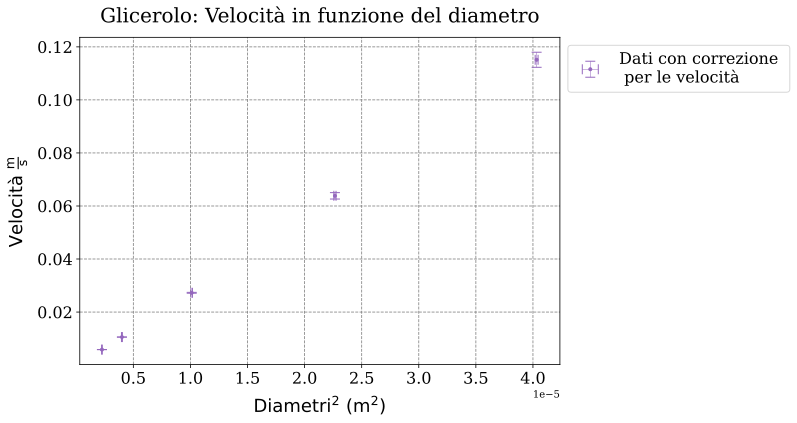

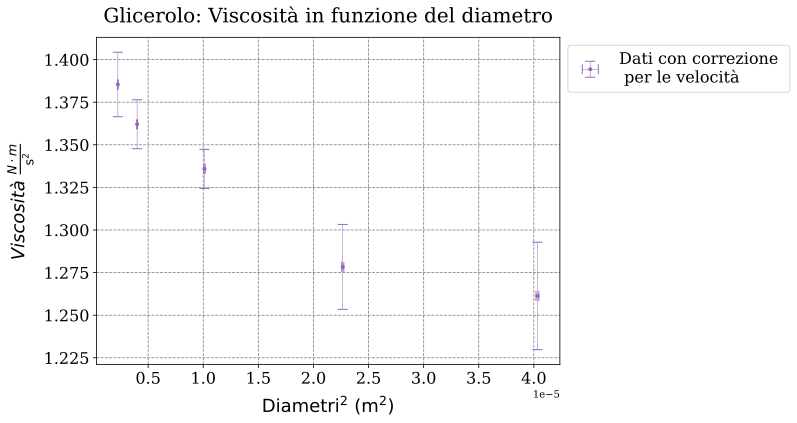

In [147]:
# Grafico 1
fig, ax = plt.subplots()

ax.errorbar(d**2, vv, xerr=2*d*sd, yerr=vsv, fmt='.', **errori, color = colore, label = "Dati con correzione \n per le velocità")

gf.setup_2d_axes(ax, titolo = f"{titolo}: Velocità in funzione del diametro", xlabel = r"$\mathrm{Diametri^2\ (m^2)}$", ylabel = r"$\mathrm{Velocità\ \frac{m}{s}}$")

gf.salva_figura(f"{nome}1.1.pdf")

# Grafico 2
fig, ax = plt.subplots()

ax.errorbar(d**2, veta, xerr=2*d*sd, yerr=vseta, fmt='.',**errori, color = colore, label = "Dati con correzione \n per le velocità")

gf.setup_2d_axes(ax, titolo = f"{titolo}: Viscosità in funzione del diametro", xlabel = r"$\mathrm{Diametri^2\ (m^2)}$", ylabel = r"${Viscosità \ \frac{N \cdot m}{\mathrm{s^2}}}$")

gf.salva_figura(f"{nome}1.2.pdf")

### 1.6 Valutazione Verifica Legge Stokes

Nome output "nome_elaborato_stokes.txt": 1 = "diametri-velocità", 2 = "diametri-viscosità".

In [148]:
d_serie = np.array(d_serie)
vv = np.array(vv)
vsv = np.array(vsv)
veta = np.array(veta)
vseta = np.array(vseta)

output_name = f"{nome}_elaborato_stokes.txt"
f.output_init(output_name)
with open (output_name, 'w') as file:
    file.write('\n')
    f.elaborato(d_serie**2, vv, vsv, output_name, 0)
    f.elaborato(d_serie**2, veta, vseta, output_name, 1)
del output_name

Processo al calcolatore

Processo al calcolatore



### 1.7 Grafici Senza Correzione Velocità

Grafici andamenti viscosità-diametro quadro e velocità-diametro quadro. Nome output "nome_eta_nocorrezione.pdf" 

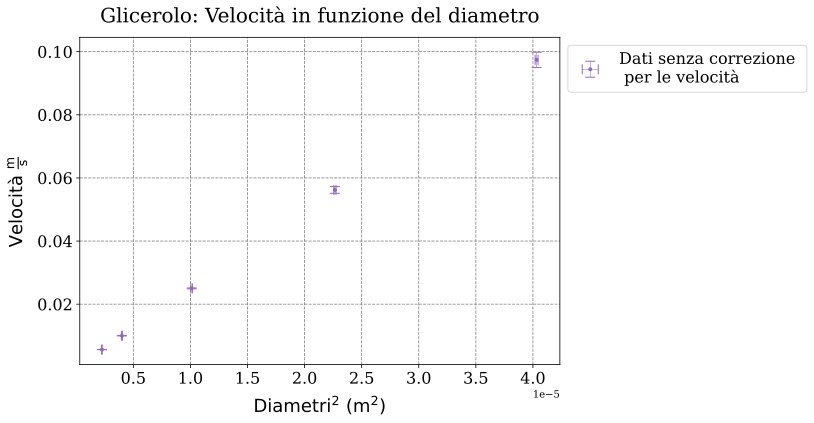

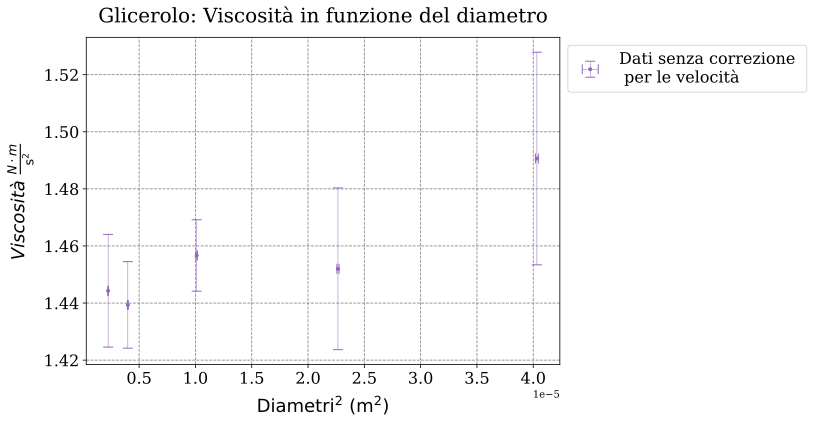

In [149]:
# Grafico 1
fig, ax = plt.subplots()

ax.errorbar(d**2, vv_falsi, xerr=2*d*sd, yerr=vsv_falsi, fmt='.', **errori, color = colore, label = "Dati senza correzione \n per le velocità")

gf.setup_2d_axes(ax, titolo = f"{titolo}: Velocità in funzione del diametro", xlabel = r"$\mathrm{Diametri^2\ (m^2)}$", ylabel = r"$\mathrm{Velocità\ \frac{m}{s}}$")

gf.salva_figura(f"{nome}1.1 nocorrezione.pdf")

# Grafico 2
fig, ax = plt.subplots()

ax.errorbar(d**2, veta_falsi, xerr=2*d*sd, yerr=vseta_falsi, fmt='.',**errori, color = colore, label = "Dati senza correzione \n per le velocità")

gf.setup_2d_axes(ax, titolo = f"{titolo}: Viscosità in funzione del diametro", xlabel = r"$\mathrm{Diametri^2\ (m^2)}$", ylabel = r"${Viscosità \ \frac{N \cdot m}{\mathrm{s^2}}}$")

gf.salva_figura(f"{nome}1.2 nocorrezione.pdf")

### 1.8 Valutazione Correzione Velocità

Nome output "nome_elaborato_nocorrezione.txt".

In [150]:
d_serie = np.array(d_serie)
vv_falsi = np.array(vv_falsi)
vsv_falsi = np.array(vsv_falsi)
veta_falsi = np.array(veta_falsi)
vseta_falsi = np.array(vseta_falsi)

output_name = f"{nome}_elaborato_nocorrezione.txt"
f.output_init(output_name)
with open (output_name, 'w') as file:
    file.write('\n')
    f.elaborato(d_serie**2, vv_falsi, vsv_falsi, output_name, 0)
    f.elaborato(d_serie**2, veta_falsi, vseta_falsi, output_name, 1)

del output_name

Processo al calcolatore

Processo al calcolatore



# 2. Intervalli di Spazio

### 2.1 Calcolo Viscosità

Dopo aver calcolato i delta si calcola la velocità con la formula v = delta_x / delta_t, da cui poi si ricavano i valori delle viscosità per ogni intervallo di spazio, cioè la viscosità media per un dato diametro per lo spazio da 0.05 a 010, da 0.10 a 0.15 e così via. Le incertezze sono ricavate con delle propagazioni.

In [151]:
veta_intervalli = []
vseta_intervalli = []
for i in range (len(t_serie)):
    veta_i = []
    vseta_i = []
    for j in range (len(t_serie[i])):
        x = x_serie[i][1] - x_serie[i][0]
        sx_int = math.sqrt (2) * sx
        if j == 0:
            t = t_serie[i][j]
            st = st_serie[i][j]
        else:
            t = t_serie[i][j] - t_serie[i][j-1]
            st = math.sqrt( st_serie[i][j]**2 + st_serie[i][j-1]**2 )
        v = x/t * correzione(d_serie[i])
        sv = v * math.sqrt( (sx_int/x)**2 + (st/t)**2 + scorrezione(d_serie[i]))
        eta = d[i]**2 * (rho - rho_0) * g / (18 * v)
        seta = eta * math.sqrt( (2 * (sd/d[i]))**2 + (srho_TOT/(rho-rho_0))**2 + (sv/v)**2 + (sg/g)**2 )
        veta_i.append(eta)
        vseta_i.append(seta)
    veta_intervalli.append(veta_i.copy())
    vseta_intervalli.append(vseta_i.copy())

del x, t, st, v, sv, eta, seta, veta_i, vseta_i

print(veta_intervalli)
print(vseta_intervalli)

[[1.351256411079465, 1.3769827849005978, 1.3761278298793513, 1.3898848334030383, 1.373562964815613, 1.3920610825480288, 1.3885246776874205, 1.4040304528454728, 1.412696587833561, 1.4086161206867038], [1.3024794747364143, 1.3460317711443983, 1.3430328649754601, 1.374248751915768, 1.356050844026986, 1.3588452793207686, 1.1996987814919085, 1.6547827926282257, 1.381200761671032, 1.3604128893636234], [1.2690625955160806, 1.3251685207915282, 1.3042957807336986, 1.3483790077358355, 1.2936089378240883, 1.3351874360192872, 1.4395511363084386, 1.367414946668577, 1.3652441817025616, 1.367915892429966], [0.6203092342400885, 1.2817449347919838, 1.3018591890580198, 1.2361286795815083, 1.297189808603405], [0.7350629240561545, 1.2139442857793241, 1.3116250253739157, 1.2544910078751925, 1.2517264586413837]]
[[0.02173567604201388, 0.03253941527307293, 0.04507003535283087, 0.045000866757122955, 0.047628491169481466, 0.061866082938639794, 0.06489366043463635, 0.06974099054690802, 0.07786958464562664, 0.09

### 2.2 Grafici Confronto Viscosità Intervalli di Spazio

Grafico 2D, nome output "nome_eta_intervalli.pdf".

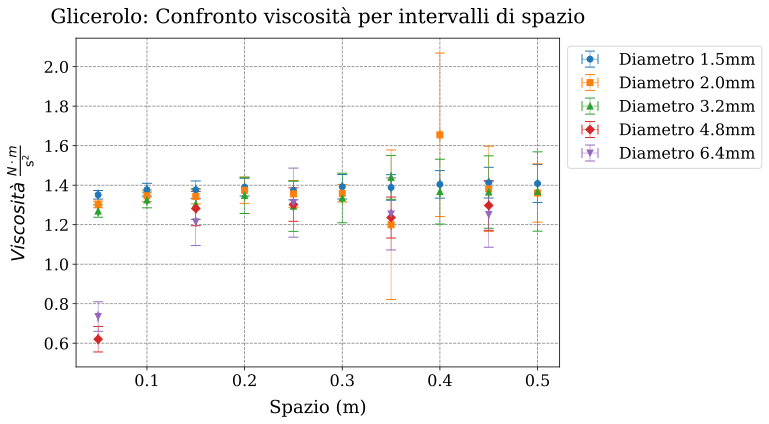

In [152]:
fig, ax = plt.subplots()

for i in range (len(veta_intervalli)):
    color = next(color_cycle)
    diameter = next(diameter_cycle)
    marker = next(marker_cycle)
    label = f"Diametro {diameter}mm"
    ax.errorbar(x_serie[i], veta_intervalli[i], xerr=sx, yerr=vseta_intervalli[i], fmt=marker, **errori, label = label)

gf.setup_2d_axes(ax, titolo = f"{titolo}: Confronto viscosità per intervalli di spazio", xlabel = "Spazio (m)", ylabel = r"${Viscosità \ \frac{N \cdot m}{\mathrm{s^2}}}$")

gf.salva_figura(f"{nome}4.1.pdf")

Grafico 3D, nome output "nome_3d_eta_intervalli.pdf" e animazione "nome_3d_eta_intervalli.gif".

In [153]:
vz_meno = []
vz_piu = []
for i in range (len(veta_intervalli)):
    for j in range (len(veta_intervalli[i])):
        vz_meno.append(veta_intervalli[i][j] - vseta_intervalli[i][j])
        vz_piu.append(veta_intervalli[i][j] + vseta_intervalli[i][j])
min_z = min(vz_meno)
max_z = max(vz_piu)

min_x = min(item for sublist in x_serie for item in sublist)
max_x = max(item for sublist in x_serie for item in sublist)

print(min_x)
print(max_x)
print(min_z)
print(max_z)

vy = []
vy_temporaneo = []
for i in range (len(veta_intervalli)):
    for j in range (len(veta_intervalli[i])):
        vy_temporaneo.append(i)
    vy.append(vy_temporaneo.copy())
    vy_temporaneo.clear()



x_plane = np.linspace(min_x, max_x, 100)
z_plane = np.linspace(min_z, max_z, 100)
X, Z = np.meshgrid(x_plane, z_plane)

0.05
0.5
0.5556370342812077
2.0685469086333805


In [154]:
fig, ax = plt.subplots(subplot_kw={'projection': '3d'})

for i in range (len(veta_intervalli)):
    Y = i * np.ones_like(X)
    color = next(color_cycle)
    diameter = next(diameter_cycle)
    marker = next(marker_cycle)
    label = f"Diametro {diameter}mm"
    ax.plot_surface(X, Y, Z, color=color, alpha=0.2)
    ax.errorbar(x_serie[i], vy[i], veta_intervalli[i], xerr=sx, zerr=vseta_intervalli[i], fmt=marker, **errori, color=color, label = label)

ax.view_init(elev=10, azim=-15)
gf.setup_3d_axes(ax, titolo = f"{titolo}: Viscosità per intervalli di spazio", xlabel = "Spazio (m)", zlabel = r"${Viscosità \ \frac{N \cdot m}{\mathrm{s^2}}}$")

gf.salva_figura(f"{nome}4.2.pdf")

"""def rotate(frame):
    ax.view_init(elev=20, azim=frame)

ani = animation.FuncAnimation(fig, rotate, frames=np.arange(0, 360, 2), interval=10000) #2
ani.save(f"{nome}_3d_eta_intervalli.gif", writer='imagemagick', fps=15)
plt.show()"""

'def rotate(frame):\n    ax.view_init(elev=20, azim=frame)\n\nani = animation.FuncAnimation(fig, rotate, frames=np.arange(0, 360, 2), interval=10000) #2\nani.save(f"{nome}_3d_eta_intervalli.gif", writer=\'imagemagick\', fps=15)\nplt.show()'

### 2.3 Valutazione Effetto Profondità

Con un interpolazione (minimi quadrati II, ordinate eta) si verifica la compatibilità della pendenza con una pendenza nulla. Nome output "nome_elaborato_profondita.txt".

In [155]:
output_name = f"{nome}_elaborato_profondita.txt"
f.output_init(output_name)
with open (output_name, 'w') as file:
    file.write('\n')
for i in range (len(x_serie)):
    f.elaborato(x_serie[i], veta_intervalli[i],vseta_intervalli[i],output_name, i)
del output_name

Minimi quadrati II
Processo al calcolatore

Minimi quadrati II
Processo al calcolatore

Minimi quadrati II
Processo al calcolatore

Minimi quadrati II
Processo al calcolatore

Minimi quadrati II
Processo al calcolatore



# 3. Intervalli di Tempo

### 3.1 Raccolta Dati

Raccolta dati in "colonne", quindi per ogni sferetta singolarmente. La lista t_tempi è una lista di liste di liste: contiene tante liste quanti sono i diametri (cinque) le quali a loro volta contengono tante liste quante sono le misure ripetute (quattro per t_tempi). La lista x_tempi è una lista di liste e contiene tante liste quanti sono i diametri.

In [156]:
x_tempi = []
t_tempi = []

with open (input_file, 'r') as input:
    
    x_t = []
    tempi1 = []
    tempi2 = []
    tempi3 = []
    tempi4 = []

    for riga in input:

        if riga.isspace():
            x_tempi.append(x_t.copy())
            t_tempi.append([tempi1.copy(), tempi2.copy(), tempi3.copy(), tempi4.copy()])
            x_t.clear()
            tempi1.clear()
            tempi2.clear()
            tempi3.clear()
            tempi4.clear()
            continue

        x0, t1, t2, t3, t4 = map(float, riga.split())

        x_t.append(x0)
        tempi1.append(t1)
        tempi2.append(t2)
        tempi3.append(t3)
        tempi4.append(t4)
        
    x_tempi.append(x_t.copy())
    t_tempi.append([tempi1.copy(), tempi2.copy(), tempi3.copy(), tempi4.copy()])
    x_t.clear()
    tempi1.clear()
    tempi2.clear()
    tempi3.clear()
    tempi4.clear()

del x0, t1, t2, t3, t4, x_t, tempi1, tempi2, tempi3, tempi4

print (x_tempi)
print (t_tempi)

[[0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5], [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5], [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5], [0.05, 0.15, 0.25, 0.35, 0.45], [0.05, 0.15, 0.25, 0.35, 0.45]]
[[[8.795, 17.759, 26.717, 35.568, 44.517, 53.555, 62.452, 71.582, 80.666, 89.946], [8.639, 17.574, 26.286, 35.299, 44.157, 53.116, 62.051, 71.085, 80.18, 89.252], [8.642, 17.454, 26.359, 35.225, 43.97, 52.997, 61.92, 70.905, 80.073, 88.965], [8.695, 17.417, 26.253, 35.288, 44.081, 52.878, 61.853, 70.833, 79.838, 88.841]], [[4.815, 9.772, 14.756, 19.737, 24.801, 29.748, 31.975, 41.006, 45.882, 50.398], [4.731, 9.783, 14.67, 19.952, 24.657, 29.708, 34.914, 40.053, 45.13, 50.309], [4.774, 9.715, 14.582, 19.609, 24.577, 29.604, 34.648, 39.71, 44.87, 50.05], [4.79, 9.589, 14.556, 19.429, 24.588, 29.5, 34.625, 39.672, 44.824, 49.909]], [[1.936, 3.891, 5.981, 7.909, 10.046, 11.787, 14.115, 16.167, 18.231, 20.322], [1.907, 3.892, 5.782, 7.906, 9.727, 11.866, 14.

### 3.2 Interpolazione

Viene fatta un'interpolazione dei dati (minimi quadrati I, ordinate spazi con incertezza costante sx definita all'inizio) ricavando quindi una velocità per ogni sferetta misurata. Nome output "nome_elaborato_temporale.txt", l'indice delle serie ha un ordine sbagliato, si ripete sempre la sequenza 1, 2, 3, 4 per tante volte quanti sono i diametri. Valutare la bontà dell'interpolazione con il test del Chi-Quadro.

In [157]:
output_name = f"{nome}_elaborato_temporale.txt"
f.output_init(output_name)
with open (output_name, 'w') as file:
    file.write('\n')
for i in range (len(t_tempi)):
    for j in range (len(t_tempi[i])):
        f.elaborato(x_tempi[i], t_tempi[i][j], sx, output_name, j)

del output_name

Minimi quadrati I
Processo al calcolatore

Minimi quadrati I
Processo al calcolatore

Minimi quadrati I
Processo al calcolatore

Minimi quadrati I
Processo al calcolatore

Minimi quadrati I
Processo al calcolatore

Minimi quadrati I
Processo al calcolatore

Minimi quadrati I
Processo al calcolatore

Minimi quadrati I
Processo al calcolatore

Minimi quadrati I
Processo al calcolatore

Minimi quadrati I
Processo al calcolatore

Minimi quadrati I
Processo al calcolatore

Minimi quadrati I
Processo al calcolatore

Minimi quadrati I
Processo al calcolatore

Minimi quadrati I
Processo al calcolatore

Minimi quadrati I
Processo al calcolatore

Minimi quadrati I
Processo al calcolatore

Minimi quadrati I
Processo al calcolatore

Minimi quadrati I
Processo al calcolatore

Minimi quadrati I
Processo al calcolatore

Minimi quadrati I
Processo al calcolatore



### 3.3 Calcolo Viscosità

Per ogni sferetta misurata viene calcolato un eta.

In [158]:
veta_tempi = []
vseta_tempi = []

for i in range (len(t_tempi)):
    veta_t = []
    vseta_t = []
    for j in range (len(t_tempi[i])):
            delta = f.delta1 (t_tempi[i][j])
            b = f.b1(t_tempi[i][j], x_tempi[i], delta)
            sb = f.sb1(t_tempi[i][j], sx, delta)
            v = b * correzione(d_serie[i])
            sv = v * math.sqrt((sb / b)**2 + scorrezione(d_serie[i])) 
            eta = d[i]**2 * (rho - rho_0) * g / (18 * v)
            seta = eta * math.sqrt( (2 * (sd/d[i]))**2 + (srho_TOT/(rho-rho_0))**2 + (sv/v)**2 + (sg/g)**2 )
            veta_t.append(eta)
            vseta_t.append(seta)
    veta_tempi.append(veta_t.copy())
    vseta_tempi.append(vseta_t.copy())

del delta, b, sb, v, sv, eta, seta, veta_t, vseta_t

print(veta_tempi)
print(vseta_tempi)

[[1.3987986385803446, 1.3914851881400705, 1.3878236106465942, 1.384583693974258], [1.3881159837192623, 1.3789151096757437, 1.3704282979816216, 1.3695179105894688], [1.36517006525196, 1.3620306706540388, 1.34515493811087, 1.3338016340735246], [1.3354388588318564, 1.2792948589818551, 1.2458659508707624, 1.2492926714196682], [1.283871299268638, 1.2608620591534607, 1.2628102672043997, 1.2462115988979876]]
[[0.01877795200101942, 0.018679773722103107, 0.018630619452660733, 0.018587125683998295], [0.014049072735792095, 0.013955934044095935, 0.013870039403086265, 0.013860825440696853], [0.008845807832844957, 0.008825465592762911, 0.008716116439742025, 0.008642550684725506], [0.005992242794657686, 0.005740313273066929, 0.005590313606453822, 0.0056056943682435195], [0.004520291888133512, 0.00443927268513859, 0.0044461335355429725, 0.004387703322772728]]


### 3.4 Grafico Andamento Temporale Eta

Nome output "nome_eta_temporale.pdf", il tempo in ascissa è convenzialmente di 1s per ogni dato, ma è completamente indicativo. E' stato usato lo stesso criterio anche per l'interpolazione successiva.

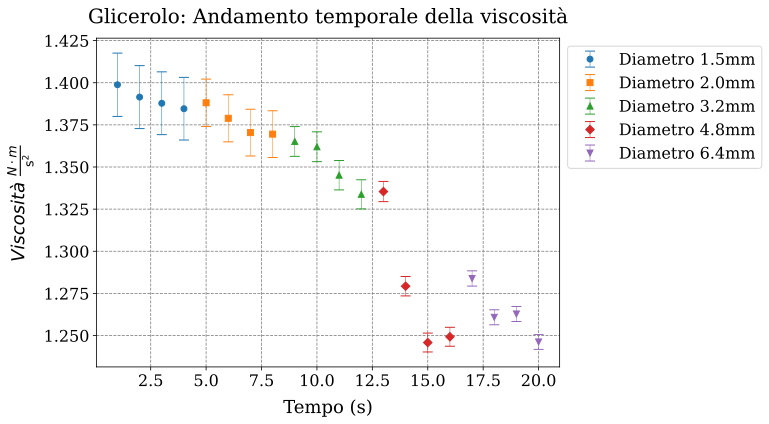

In [159]:
ascisse = [[1,2,3,4], [5,6,7,8], [9,10,11,12], [13,14,15,16], [17,18,19,20]] #tempi indicativi

fig, ax = plt.subplots()
for i in range (len(veta_tempi)):
    color = next(color_cycle)
    diameter = next(diameter_cycle)
    marker = next(marker_cycle)
    label = f"Diametro {diameter}mm"
    ax.errorbar(ascisse[i], veta_tempi[i], yerr=vseta_tempi[i], fmt=marker, **errori, color=color, label = label)

gf.setup_2d_axes(ax, titolo = f"{titolo}: Andamento temporale della viscosità", xlabel = "Tempo (s)", ylabel = r"${Viscosità \ \frac{N \cdot m}{\mathrm{s^2}}}$")
gf.salva_figura(f"{nome}5.pdf")

### 3.5 Valutazione Effetto Memoria

E' stata fatta un'interpolazione (minimi quadrati 2, ordinate eta) di cui serve verificare la compatibilità della pendenza con la pendenza nulla. Si ricordi che il tempo nell'ascisse è indicativo.

In [160]:
output_name = f"{nome}_elaborato_memoria.txt"
f.output_init(output_name)
with open (output_name, 'w') as file:
    file.write('\n')
for i in range (len(veta_tempi)):
    f.elaborato(ascisse[i], veta_tempi[i],vseta_tempi[i], output_name, i)

del output_name

Minimi quadrati II
Processo al calcolatore

Minimi quadrati II
Processo al calcolatore

Minimi quadrati II
Processo al calcolatore

Minimi quadrati II
Processo al calcolatore

Minimi quadrati II
Processo al calcolatore



# 4. Confronto Glicerolo-Sapone

### 4.1 Dati

In [161]:
d_g = [0.0015, 0.002, 0.00318, 0.00476, 0.00635]
vv_g = [0.005848584630897728, 0.010575679262215221, 0.027260964308315698, 0.06382788558202258, 0.11512694303169776]
vsv_g = [1.5107723646593004e-05, 3.106982273421193e-05, 0.0001543042201740087, 0.0012116548845597988, 0.002848823025224685]
veta_g = [1.3854106216688666, 1.3620670712239062, 1.3358564733519138, 1.2783513108446085, 1.261296675770493]
vseta_g = [0.018933674032854793, 0.014347230349116273, 0.011484947896080115, 0.024930684589884042, 0.03152131567049107]

d_s = [0.0015, 0.002, 0.00318, 0.00476, 0.00635]
vv_s = [0.0011062374207969241, 0.002057759304913559, 0.0053914704394030545, 0.01404328788939443, 0.03942497045810502]
vsv_s =[1.1565134732745702e-05, 1.0765982305142885e-05, 2.3995212166598997e-05, 5.329079430070025e-05, 0.0012170853151817196]
veta_s = [7.577197081334085, 7.241688297544369, 6.987493583397883, 6.010623387790249, 3.8102237916845803]
vseta_s = [0.12839427058286382, 0.08174641048267421, 0.05386097662866154, 0.03405824925154938, 0.11823899926893798]

d_g = np.array(d_g)
vv_g = np.array(vv_g)
vsv_g = np.array(vsv_g)
veta_g = np.array(veta_g)
vseta_g = np.array(vseta_g)

d_s = np.array(d_s)
vv_s = np.array(vv_s)
vsv_s = np.array(vsv_s)
veta_s = np.array(veta_s)
vseta_s = np.array(vseta_s)

rho_g = 1260
srho_g = 10
rho_s = 1032
srho_s = 1

#superficie
d_values = np.linspace(0.000001, 0.007, 50)
veta_values = np.linspace(1.261296675770493, 7.577197081334085, 50)
D, VETA = np.meshgrid(d_values, veta_values)
VV_s = (rho - rho_s) * g * D ** 2 / (18 * VETA)
VV_g = (rho - rho_g) * g * D ** 2 / (18 * VETA)

### 4.2 Grafico Confronto

Nome output "confronto.png" e animazione "confronto.gif". La superficie è indicativa e, anche se i dati sembrano (qualitativamente) seguirla, non va intesa come una verifica della Legge di Stokes. Teoricamente le superfici dovrebero essere due (perchè le densità variano tra glicerolo e sapone), ma, essendo esse estremamente vicine (almeno per quanto riguarda l'ingrandimento di questo grafico) si è deciso di mantenere una densità media tra glicerolo e sapone (sottratta alla densità delle sferette, come da Legge di Stokes).

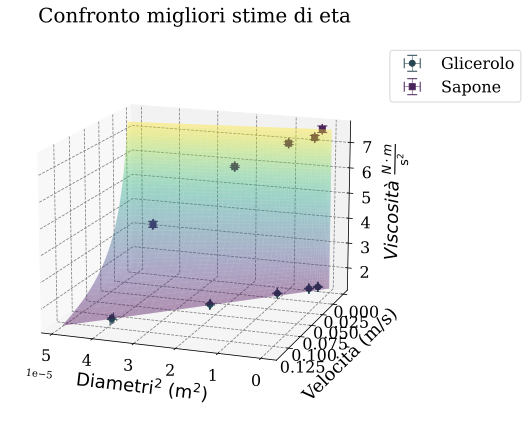

'def rotate(frame):\n    ax.view_init(elev=15, azim=frame)\n\nani = animation.FuncAnimation(fig, rotate, frames=np.arange(0, 360, 2), interval=10000)\nani.save(f"confronto.gif", writer=\'imagemagick\', fps=15)\nplt.show()'

In [162]:
fig, ax = plt.subplots(subplot_kw={'projection': '3d'})

ax.errorbar(d_g**2, vv_g, veta_g, xerr = 2*d_g*sd, yerr = vsv_g, zerr = vseta_g, color = "#264653", fmt ="o", **errori, label = "Glicerolo")
ax.errorbar(d_s**2, vv_s, veta_s, xerr = 2*d_s*sd, yerr = vsv_s, zerr = vseta_s, color = "#4A235A", fmt ="s", **errori, label = "Sapone")
ax.plot_surface(D**2, VV_g, VETA, cmap = "viridis", alpha=0.4, edgecolor='none')

ax.view_init(elev=15, azim=110)

gf.setup_3d_axes(ax, titolo = "Confronto migliori stime di eta", xlabel = r"$\mathrm{Diametri^2\ (m^2)}$", ylabel = "Velocità (m/s)", zlabel = r"${Viscosità \ \frac{N \cdot m}{\mathrm{s^2}}}$")

gf.salva_figura("confronto.pdf")

"""def rotate(frame):
    ax.view_init(elev=15, azim=frame)

ani = animation.FuncAnimation(fig, rotate, frames=np.arange(0, 360, 2), interval=10000)
ani.save(f"confronto.gif", writer='imagemagick', fps=15)
plt.show()"""

Come si può vedere i dati del sapone sono vistosamente superiori, ma soprattutto sembrano crescere. La viscosità è costante per un materiale, il chè vuol dire che le rette dei dati di sapone e glicerolo dovrebbero essere orizzontali. Nel grafico che mette a confronto viscosità in funzione del diametro quadrato si può quantificare quanto questa affermazione è corrispondente ai dati attraverso un confronto della pendenza della retta interpolante con una costante.


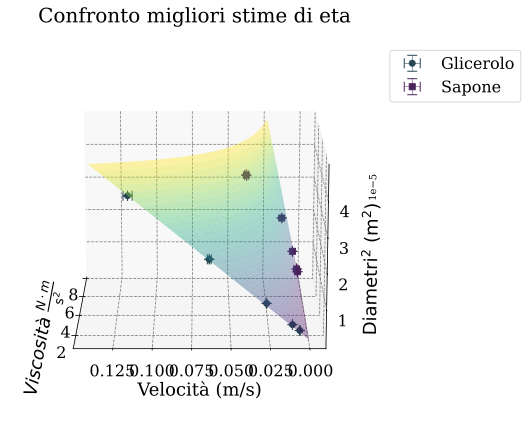

'def rotate(frame):\n    ax.view_init(elev=15, azim=frame)\n\nani = animation.FuncAnimation(fig, rotate, frames=np.arange(0, 360, 2), interval=10000)\nani.save(f"confronto(2).gif", writer=\'imagemagick\', fps=15)\nplt.show()'

In [163]:
fig, ax = plt.subplots(subplot_kw={'projection': '3d'})

ax.errorbar(veta_g, vv_g, d_g**2, xerr = vseta_g, yerr = vsv_g, zerr = 2*d_s*sd, color = "#264653", fmt ="o", **errori, label = "Glicerolo")
ax.errorbar(veta_s, vv_s, d_s**2, xerr = vseta_s, yerr = vsv_s, zerr = 2*d_s*sd, color = "#4A235A", fmt ="s", **errori, label = "Sapone")
ax.plot_surface(VETA, VV_g, D**2, cmap = "viridis", alpha=0.4, edgecolor='none')

ax.view_init(elev=15, azim=180)

gf.setup_3d_axes(ax, titolo = "Confronto migliori stime di eta", xlabel =  r"${Viscosità \ \frac{N \cdot m}{\mathrm{s^2}}}$", ylabel = "Velocità (m/s)", zlabel = r"$\mathrm{Diametri^2\ (m^2)}$")

gf.salva_figura("confronto(2).pdf")

"""def rotate(frame):
    ax.view_init(elev=15, azim=frame)

ani = animation.FuncAnimation(fig, rotate, frames=np.arange(0, 360, 2), interval=10000)
ani.save(f"confronto(2).gif", writer='imagemagick', fps=15)
plt.show()"""